# 🌍 Customer Intelligence System
### Week 3 Assignment — Classification, Ensemble Learning & Clustering
**Dataset:** [Unsupervised Learning on Country Data — Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

---
### 📚 All Algorithms Covered:
| Category | Algorithms |
|---|---|
| **Classification** | Logistic Regression, Naive Bayes, K-Nearest Neighbors, SVM, Decision Tree |
| **Ensemble** | Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM, Stacking |
| **Evaluation** | Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC |
| **Clustering** | K-Means, K-Medoids, DBSCAN, Hierarchical Clustering |
| **Visualization** | Elbow Method, PCA 2D Plot, Dendrogram, Feature Importance |


## Step 0 — Install Required Libraries

In [1]:
# We install all libraries we need before importing them
# This is especially important in Google Colab where some packages may not be pre-installed
!pip install xgboost lightgbm scikit-learn-extra --quiet
# xgboost and lightgbm are advanced boosting libraries
# scikit-learn-extra gives us KMedoids which is not in standard scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 31.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Step 1 — Import All Libraries

In [2]:
# We import pandas to load and work with tabular data (rows and columns)
import pandas as pd

# We import numpy for doing math operations on arrays and numbers
import numpy as np

# We import matplotlib for drawing charts and graphs
import matplotlib.pyplot as plt

# We import seaborn which makes it easier to create beautiful statistical plots
import seaborn as sns

# We import os to interact with the file system (create folders, check paths)
import os

# We import warnings to suppress unimportant warning messages
import warnings
warnings.filterwarnings('ignore')  # This hides all warning messages so output stays clean

# ---- Preprocessing ----
from sklearn.preprocessing import StandardScaler, LabelEncoder
# StandardScaler scales features to mean=0, std=1 — needed before clustering and SVM
# LabelEncoder converts text labels to numbers

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# train_test_split divides data into training and testing portions
# cross_val_score tests the model on multiple splits for reliability
# GridSearchCV finds the best hyperparameters automatically

# ---- Classification Models ----
from sklearn.linear_model import LogisticRegression
# LogisticRegression is a simple but powerful linear classification model

from sklearn.naive_bayes import GaussianNB
# GaussianNB is Naive Bayes — it assumes features follow a normal distribution
# It is very fast and works well even with small datasets

from sklearn.neighbors import KNeighborsClassifier
# KNeighborsClassifier predicts based on the k closest data points (majority vote)

from sklearn.svm import SVC
# SVC is Support Vector Machine — it finds the best boundary line between classes
# It works very well for small-to-medium datasets with clear margins

from sklearn.tree import DecisionTreeClassifier, export_text
# DecisionTreeClassifier splits data using simple if-else rules
# export_text lets us print the tree as text to understand its decisions

# ---- Ensemble Models ----
from sklearn.ensemble import (
    RandomForestClassifier,      # Many decision trees voting together (bagging)
    AdaBoostClassifier,          # Focuses on misclassified samples (boosting)
    GradientBoostingClassifier,  # Trees built sequentially fixing previous errors
    StackingClassifier           # Combines multiple models using a meta-learner
)

from xgboost import XGBClassifier
# XGBoost is an optimized and very fast gradient boosting model
# It is one of the most popular models in machine learning competitions

from lightgbm import LGBMClassifier
# LightGBM is another fast gradient boosting model — uses leaf-wise tree growth
# It is faster than XGBoost on large datasets

# ---- Clustering Models ----
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
# KMeans groups data into k clusters based on distance to cluster centers
# DBSCAN groups dense regions and marks sparse points as outliers
# AgglomerativeClustering builds a tree of clusters (hierarchical)

try:
    from sklearn_extra.cluster import KMedoids
    # KMedoids is like KMeans but uses actual data points as cluster centers
    # It is more robust to outliers than KMeans
    kmedoids_available=True
except:
    kmedoids_available=False
    print("Note: scikit-learn-extra not available, KMedoids will be skipped")

# ---- Evaluation Metrics ----
from sklearn.metrics import (
    classification_report,  # Detailed precision, recall, F1 for each class
    confusion_matrix,       # Table showing correct vs wrong predictions
    accuracy_score,         # Simple % of correct predictions
    roc_auc_score,          # Area under ROC curve — measures separability
    silhouette_score        # Measures how well-separated the clusters are
)

from scipy.cluster.hierarchy import dendrogram, linkage
# dendrogram draws the tree diagram for hierarchical clustering
# linkage computes the distances between clusters step by step

print("✅ All libraries imported successfully!")

Note: scikit-learn-extra not available, KMedoids will be skipped
✅ All libraries imported successfully!



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

## Step 2 — Load the Dataset
Download `Country-data.csv` from [Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) and upload it using the button below.

In [3]:
# We import the files module from Google Colab
# This module allows us to upload files directly from our computer into Colab
from google.colab import files

# This line opens a file browser button in the output
# Click "Choose Files" and select Country-data.csv downloaded from Kaggle
uploaded=files.upload()

# Now we load the uploaded CSV file into a pandas DataFrame
df=pd.read_csv('Country-data.csv')
# read_csv reads the file row by row and stores it in a table structure

print(f"Dataset Shape : {df.shape}")   # rows x columns
print(f"Columns       : {list(df.columns)}")

print("\nFirst 5 rows:")
df.head()  # head() shows first 5 rows as a nice table in Jupyter

Dataset Shape : (167, 10)
Columns       : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

First 5 rows:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Basic Statistical Summary

In [4]:
# describe() gives count, mean, std, min, max for every numeric column
# It helps us understand the range and spread of the data before modeling
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Step 3 — Data Cleaning & Preprocessing
We clean the dataset by:
1. Stripping whitespace from column names
2. Dropping duplicate rows
3. Checking for missing values
4. Converting all columns to numeric
5. Filling missing values with the **median**

In [5]:
# Step 3.1 — Strip whitespace from column names
df.columns=df.columns.str.strip()
# .strip() removes leading and trailing spaces to avoid 'column not found' errors

# Step 3.2 — Drop duplicate rows
before=len(df)  # store original row count
df=df.drop_duplicates()  # remove rows that are exact copies of another row
after=len(df)
print(f"Duplicates removed: {before - after} rows")

# Step 3.3 — Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())  # counts NaN (empty) values in each column

# Step 3.4 — Separate the country name column (it is a label, not a number)
country_col='country'
countries=df[country_col].values  # save country names as a numpy array
df_num=df.drop(columns=[country_col])  # remove country column from features

# Step 3.5 — Convert all columns to numeric, bad values become NaN
for col in df_num.columns:
    df_num[col]=pd.to_numeric(df_num[col], errors='coerce')
    # errors='coerce' turns any non-numeric value into NaN instead of crashing

# Step 3.6 — Fill missing values with the median of each column
for col in df_num.columns:
    if df_num[col].isnull().any():  # only fill if there are missing values
        median_val=df_num[col].median()
        # median is used because it is less affected by very high or very low values
        df_num[col].fillna(median_val, inplace=True)
        print(f"  Filled '{col}' with median = {median_val:.2f}")

print("\n✅ After cleaning — missing values per column:")
print(df_num.isnull().sum())

Duplicates removed: 0 rows

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

✅ After cleaning — missing values per column:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Step 4 — Exploratory Data Analysis (EDA)
We create 5 charts to understand the data visually before applying any models.

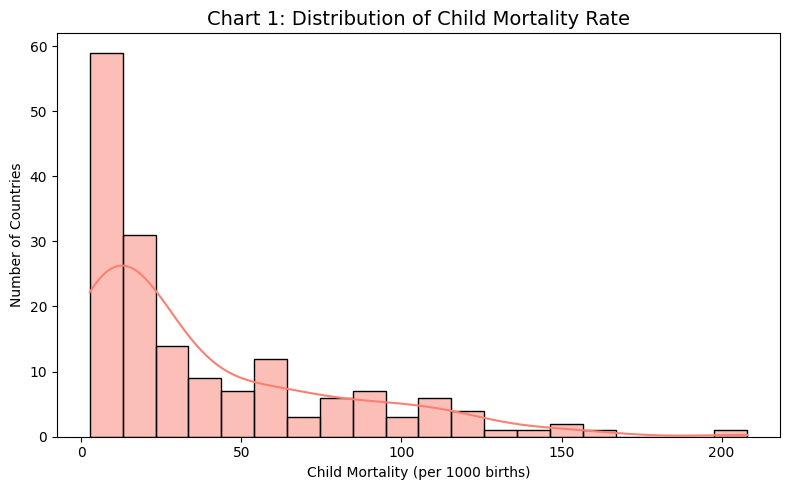

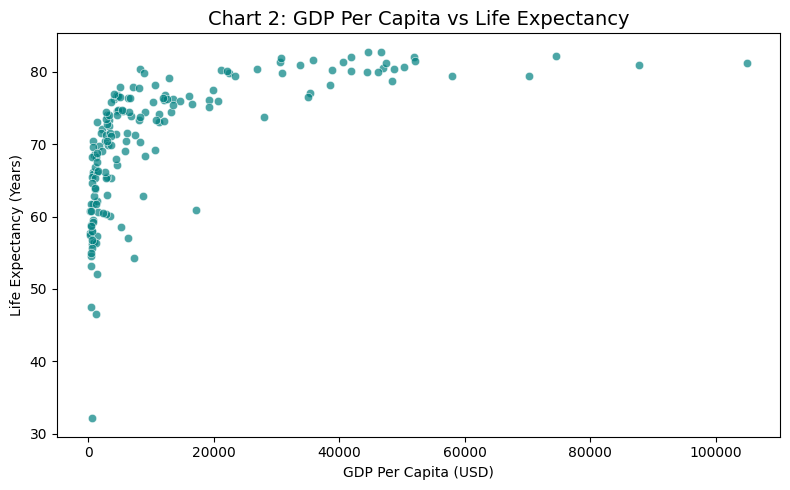

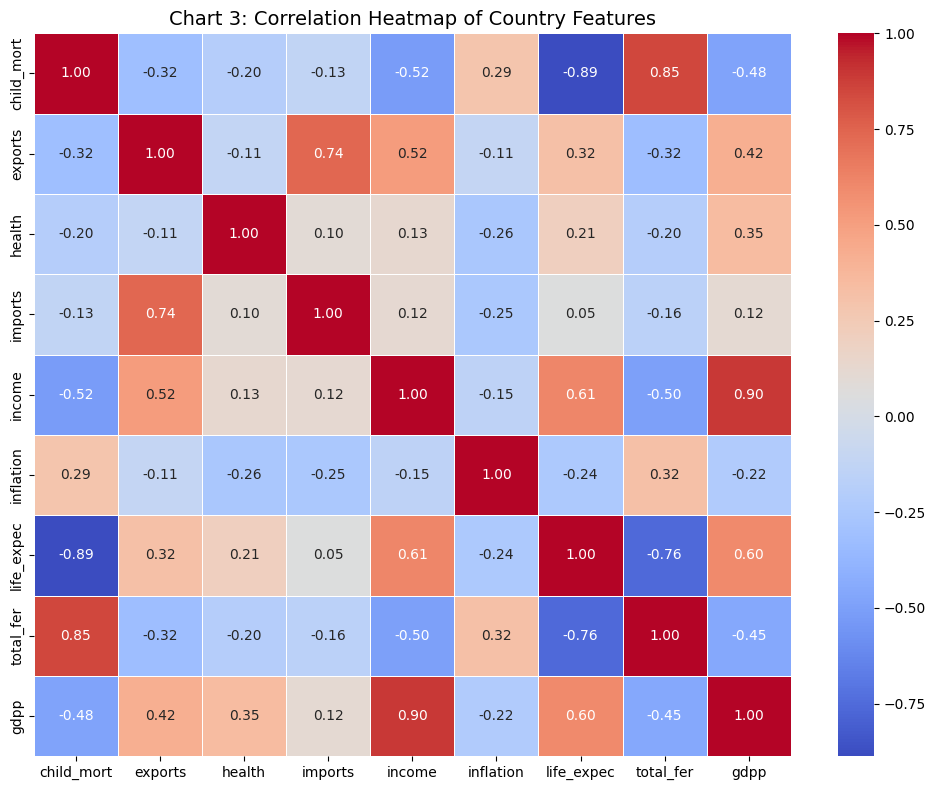

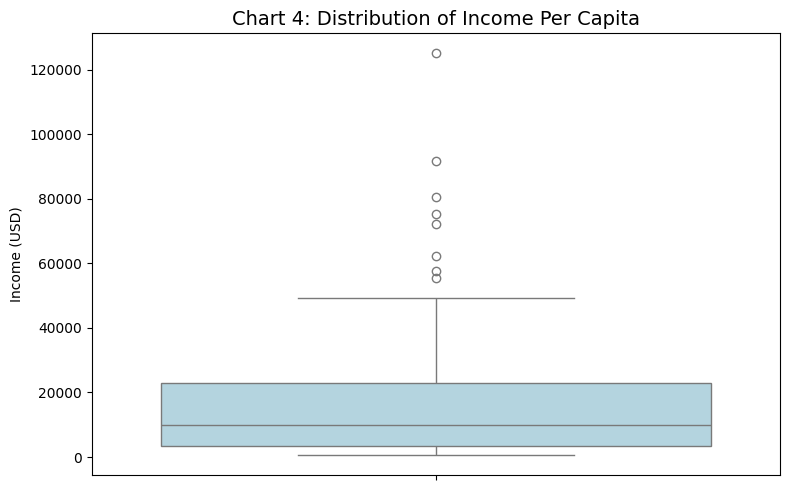

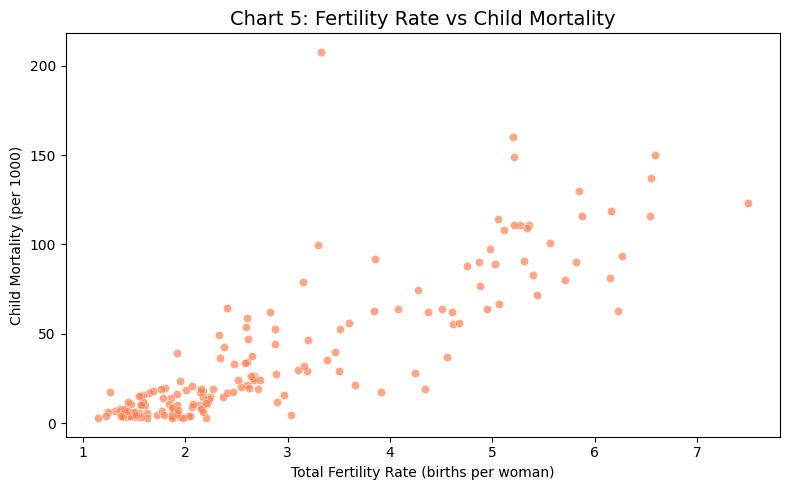

✅ All 5 EDA charts generated!


In [6]:
# We create a folder to save all plots
plot_folder='plots'
os.makedirs(plot_folder, exist_ok=True)
# exist_ok=True means no error if folder already exists

# -------------------------------------------------------
# Chart 1: Distribution of Child Mortality Rate
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df_num['child_mort'], kde=True, color='salmon', bins=20)
# histplot draws a histogram; kde=True adds a smooth density curve on top
plt.title('Chart 1: Distribution of Child Mortality Rate', fontsize=14)
plt.xlabel('Child Mortality (per 1000 births)')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.savefig(f'{plot_folder}/01_child_mortality_distribution.png')
plt.show()

# -------------------------------------------------------
# Chart 2: GDP Per Capita vs Life Expectancy
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_num['gdpp'], y=df_num['life_expec'], color='teal', alpha=0.7)
# scatterplot shows relationship between two variables as dots
plt.title('Chart 2: GDP Per Capita vs Life Expectancy', fontsize=14)
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Life Expectancy (Years)')
plt.tight_layout()
plt.savefig(f'{plot_folder}/02_gdp_vs_life_expectancy.png')
plt.show()

# -------------------------------------------------------
# Chart 3: Correlation Heatmap
# -------------------------------------------------------
plt.figure(figsize=(10, 8))
corr_matrix=df_num.corr()
# .corr() computes correlation between every pair of columns (-1 to +1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# annot=True shows the number inside each cell
plt.title('Chart 3: Correlation Heatmap of Country Features', fontsize=14)
plt.tight_layout()
plt.savefig(f'{plot_folder}/03_correlation_heatmap.png')
plt.show()

# -------------------------------------------------------
# Chart 4: Income Distribution (Box Plot)
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_num['income'], color='lightblue')
# boxplot shows spread of data and highlights outliers as dots
plt.title('Chart 4: Distribution of Income Per Capita', fontsize=14)
plt.ylabel('Income (USD)')
plt.tight_layout()
plt.savefig(f'{plot_folder}/04_income_boxplot.png')
plt.show()

# -------------------------------------------------------
# Chart 5: Fertility Rate vs Child Mortality
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_num['total_fer'], y=df_num['child_mort'], color='coral', alpha=0.7)
plt.title('Chart 5: Fertility Rate vs Child Mortality', fontsize=14)
plt.xlabel('Total Fertility Rate (births per woman)')
plt.ylabel('Child Mortality (per 1000)')
plt.tight_layout()
plt.savefig(f'{plot_folder}/05_fertility_vs_child_mortality.png')
plt.show()

print("✅ All 5 EDA charts generated!")

## Step 5 — Feature Scaling with StandardScaler
All features must be on the same scale before clustering and SVM.
`StandardScaler` transforms each feature to **mean=0, std=1**.

In [7]:
scaler=StandardScaler()
# StandardScaler makes all features have the same scale
# This is critical for distance-based models like KMeans, KNN, SVM

X_scaled=scaler.fit_transform(df_num)
# fit learns the mean and std of each column
# transform applies: scaled = (value - mean) / std

print(f"Scaled data shape : {X_scaled.shape}")
print(f"Mean of first feature (should be ~0) : {X_scaled[:, 0].mean():.4f}")
print(f"Std  of first feature (should be ~1) : {X_scaled[:, 0].std():.4f}")
print("\n✅ Scaling complete!")

Scaled data shape : (167, 9)
Mean of first feature (should be ~0) : -0.0000
Std  of first feature (should be ~1) : 1.0000

✅ Scaling complete!


## Step 6 — Elbow Method (Finding Optimal K for K-Means)
We test K-Means for k=2 to 10 and look for the **elbow** — the point where adding more clusters stops helping much.

  k=2: Inertia = 1050.21
  k=3: Inertia = 831.42
  k=4: Inertia = 700.52
  k=5: Inertia = 620.16
  k=6: Inertia = 558.47
  k=7: Inertia = 495.81
  k=8: Inertia = 457.59
  k=9: Inertia = 427.80
  k=10: Inertia = 403.23


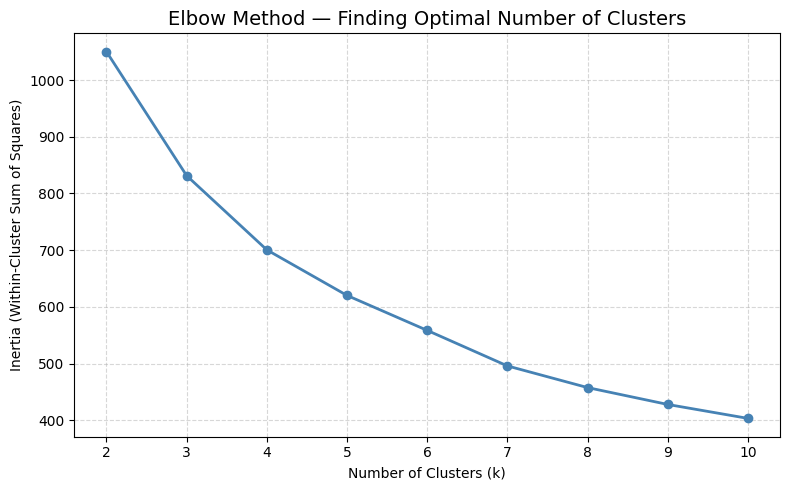

✅ Elbow plot done — the bend point is the best k (we use k=3)


In [8]:
inertia_values=[]  # stores inertia for each k
k_range=range(2, 11)  # we test k from 2 to 10

for k in k_range:
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    # n_init=10 means tries 10 random starts and picks the best result
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    # inertia = sum of squared distances from each point to its cluster center
    print(f"  k={k}: Inertia = {km.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia_values, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Finding Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{plot_folder}/06_elbow_method.png')
plt.show()
print("✅ Elbow plot done — the bend point is the best k (we use k=3)")

## Step 7 — K-Means Clustering
We train K-Means with **k=3** based on the elbow plot.
Then we measure quality using the **Silhouette Score**.

In [9]:
best_k=3  # chosen from the elbow plot

kmeans=KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
kmeans_labels=kmeans.labels_
# .labels_ gives the cluster number (0, 1, or 2) assigned to each country

df['KMeans_Cluster']=kmeans_labels
# we add cluster labels back to the dataframe so we can analyze each group

sil_score=silhouette_score(X_scaled, kmeans_labels)
# silhouette score ranges from -1 to 1; closer to 1 means better-separated clusters
print(f"✅ K-Means Silhouette Score (k={best_k}): {sil_score:.4f}")
print("   (Closer to 1 = well-separated, closer to 0 = overlapping)")

print("\nCluster sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

print("\nCluster profile (mean features per cluster):")
cluster_profile=df.groupby('KMeans_Cluster')[list(df_num.columns)].mean().round(2)
cluster_profile

✅ K-Means Silhouette Score (k=3): 0.2833
   (Closer to 1 = well-separated, closer to 0 = overlapping)

Cluster sizes:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64

Cluster profile (mean features per cluster):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Step 8 — K-Medoids Clustering
K-Medoids is similar to K-Means but uses **actual data points** as cluster centers (called medoids).
This makes it more robust to outliers compared to K-Means.

In [10]:
if kmedoids_available:
    kmedoids=KMedoids(n_clusters=3, random_state=42)
    # KMedoids finds 3 actual countries that best represent each cluster
    kmedoids.fit(X_scaled)
    kmedoids_labels=kmedoids.labels_
    # .labels_ gives the cluster number assigned to each country

    df['KMedoids_Cluster']=kmedoids_labels

    kmed_sil=silhouette_score(X_scaled, kmedoids_labels)
    # we measure how well-separated the K-Medoids clusters are
    print(f"✅ K-Medoids Silhouette Score: {kmed_sil:.4f}")

    print("\nK-Medoids cluster sizes:")
    print(pd.Series(kmedoids_labels).value_counts().sort_index())

    # Show which actual countries are the medoids (cluster representatives)
    medoid_indices=kmedoids.medoid_indices_
    # medoid_indices_ gives the row numbers of the chosen medoid countries
    print("\nMedoid countries (cluster representatives):")
    for i, idx in enumerate(medoid_indices):
        print(f"  Cluster {i} medoid: {countries[idx]}")
else:
    print("KMedoids skipped — scikit-learn-extra not installed")
    print("Run: !pip install scikit-learn-extra and restart runtime")
    kmedoids_labels=kmeans_labels  # fallback to kmeans labels
    df['KMedoids_Cluster']=kmedoids_labels

KMedoids skipped — scikit-learn-extra not installed
Run: !pip install scikit-learn-extra and restart runtime


## Step 9 — DBSCAN Clustering (Density-Based)
DBSCAN finds clusters based on **density** — no need to specify k in advance.
Points in sparse regions are labeled **-1 (noise/outlier)**.

In [11]:
dbscan=DBSCAN(eps=1.5, min_samples=5)
# eps=1.5 means two points are neighbors if their distance is at most 1.5
# min_samples=5 means a cluster needs at least 5 nearby points to form
dbscan_labels=dbscan.fit_predict(X_scaled)
# fit_predict trains and returns cluster label for each point in one step

df['DBSCAN_Cluster']=dbscan_labels

n_clusters_found=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# we count unique labels but subtract 1 because -1 means noise, not a real cluster
n_noise=list(dbscan_labels).count(-1)
# count how many points were marked as noise/outliers

print(f"✅ DBSCAN found {n_clusters_found} cluster(s) and {n_noise} noise point(s)")
print("\nDBSCAN cluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())
# -1 = noise points, 0,1,2... = actual clusters

✅ DBSCAN found 1 cluster(s) and 30 noise point(s)

DBSCAN cluster distribution:
-1     30
 0    137
Name: count, dtype: int64


## Step 10 — Hierarchical Clustering + Dendrogram
Hierarchical clustering builds a **tree of clusters** by merging the closest countries step by step.
The **dendrogram** diagram shows us this merging process visually.

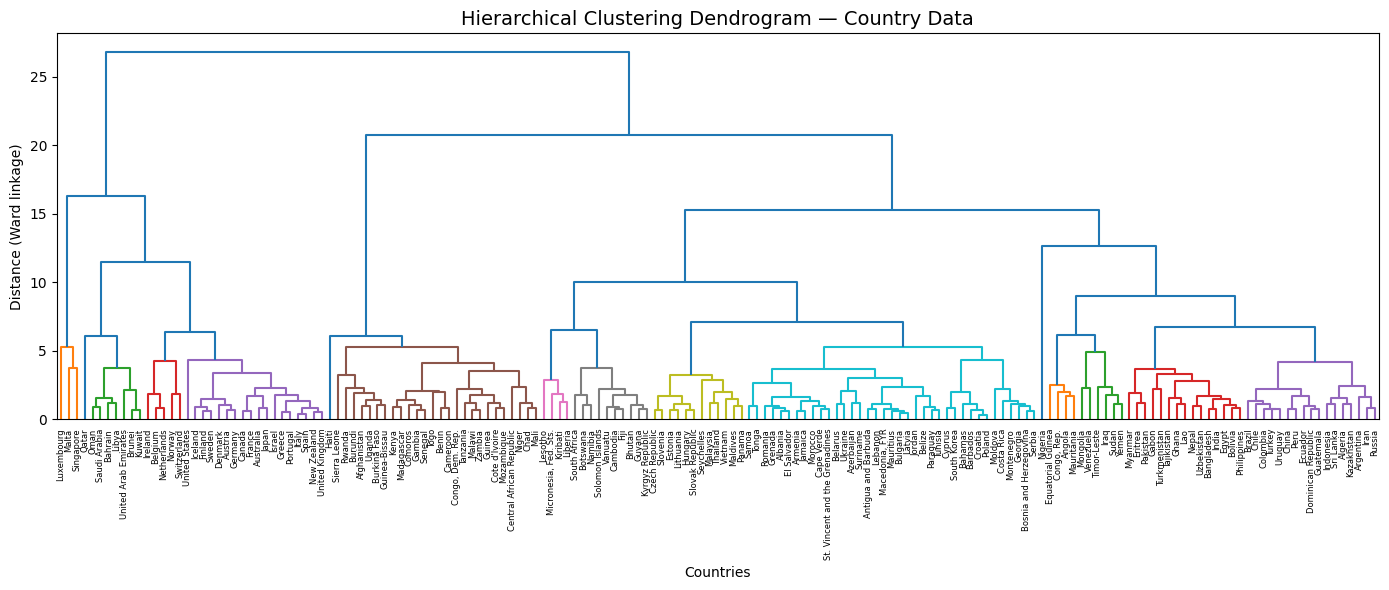

✅ Hierarchical Clustering Silhouette Score: 0.2456

Hierarchical cluster sizes:
0     34
1    106
2     27
Name: count, dtype: int64


In [12]:
# We compute the linkage matrix — this records how clusters are merged step by step
linkage_matrix=linkage(X_scaled, method='ward')
# method='ward' minimizes the total variance within each cluster at every merge step

# Draw the Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix,
           labels=countries,
           leaf_rotation=90,
           leaf_font_size=6,
           color_threshold=6)
# leaf_rotation=90 rotates country name labels so they don't overlap
# color_threshold=6 colors branches that are below this distance in different colors
plt.title('Hierarchical Clustering Dendrogram — Country Data', fontsize=14)
plt.xlabel('Countries')
plt.ylabel('Distance (Ward linkage)')
plt.tight_layout()
plt.savefig(f'{plot_folder}/07_dendrogram.png')
plt.show()

# Now we actually assign cluster labels using AgglomerativeClustering
hier=AgglomerativeClustering(n_clusters=3, linkage='ward')
# n_clusters=3 means we cut the dendrogram tree to get 3 groups
hier_labels=hier.fit_predict(X_scaled)
# fit_predict trains and immediately returns the cluster label for each country

df['Hierarchical_Cluster']=hier_labels

hier_sil=silhouette_score(X_scaled, hier_labels)
# we measure quality of the hierarchical clusters using silhouette score
print(f"✅ Hierarchical Clustering Silhouette Score: {hier_sil:.4f}")

print("\nHierarchical cluster sizes:")
print(pd.Series(hier_labels).value_counts().sort_index())

## Step 11 — PCA 2D Visualization of All Clustering Methods
PCA compresses 9 features into 2 dimensions so we can plot and compare all clustering results.

PCA Component 1 explains : 45.95% of variance
PCA Component 2 explains : 17.18% of variance
Total variance explained : 63.13%


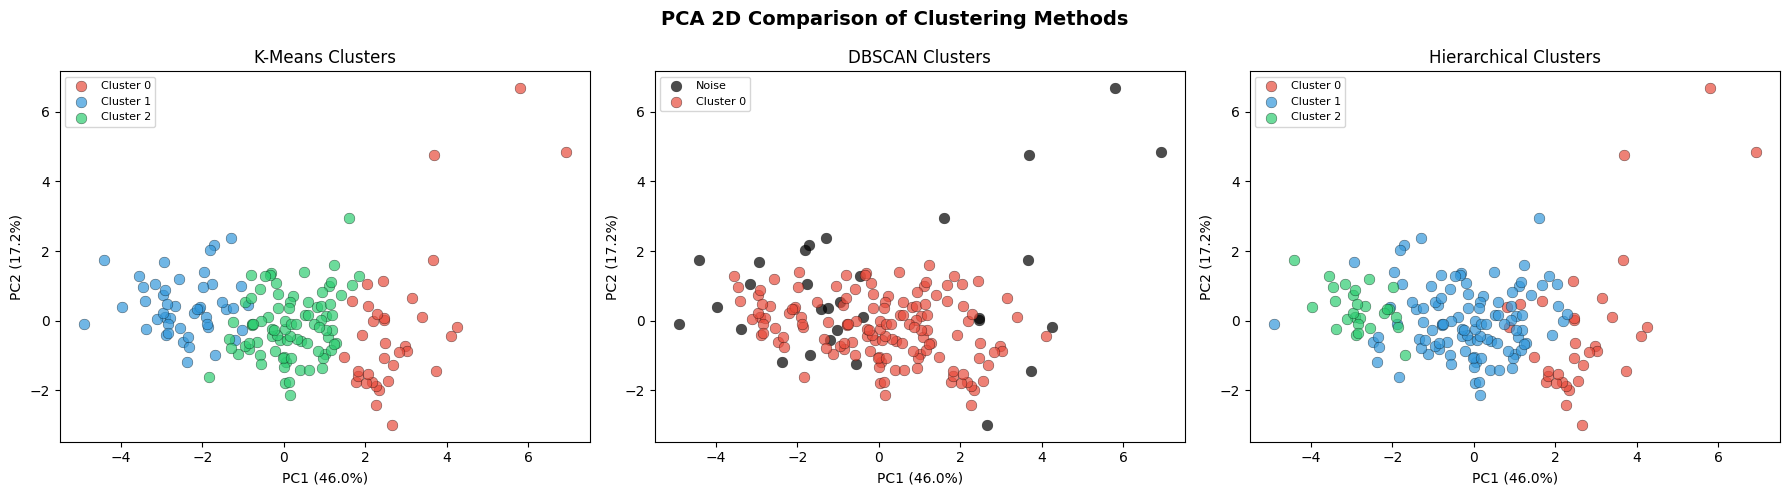

✅ PCA comparison plot saved!


In [16]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
# PCA finds the 2 most important directions of variation in the data
X_pca=pca.fit_transform(X_scaled)
# fit finds the best 2D projection; transform applies it to all data points

explained=pca.explained_variance_ratio_
print(f"PCA Component 1 explains : {explained[0]*100:.2f}% of variance")
print(f"PCA Component 2 explains : {explained[1]*100:.2f}% of variance")
print(f"Total variance explained : {sum(explained)*100:.2f}%")

pca_df=pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1]})
# we store both PCA dimensions in a clean table for easy plotting

colors=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes=plt.subplots(1, 3, figsize=(18, 5))
# we create 3 subplots side by side to compare all 3 clustering methods

clustering_methods=[
    ('KMeans_Cluster', 'K-Means Clusters'),
    ('DBSCAN_Cluster', 'DBSCAN Clusters'),
    ('Hierarchical_Cluster', 'Hierarchical Clusters')
]

for ax, (col, title) in zip(axes, clustering_methods):
    labels_to_plot=df[col].values
    unique_labels=sorted(set(labels_to_plot))
    for label in unique_labels:
        mask=labels_to_plot==label
        # mask selects only the countries belonging to this cluster
        color=colors[label % len(colors)] if label != -1 else 'black'
        # noise points (-1) are shown in black so they stand out
        name='Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                   label=name, color=color, alpha=0.7, s=60,
                   edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
    ax.legend(fontsize=8)

plt.suptitle('PCA 2D Comparison of Clustering Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plot_folder}/08_pca_all_clusters.png')
plt.show()
print("✅ PCA comparison plot saved!")

## Step 12 — Create Target Variable & Train-Test Split
We use the **K-Means cluster labels** as the target for all classification models.
Split: **80% training / 20% testing** with stratification.

In [15]:
y=kmeans_labels.copy()
# y is our target variable — the cluster (0, 1, or 2) each country belongs to

print(f"Feature matrix shape : {X_scaled.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Unique classes       : {np.unique(y)}")

X_train, X_test, y_train, y_test=train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
# test_size=0.2 means 20% for testing, 80% for training
# stratify=y ensures each cluster is equally represented in both splits
# random_state=42 makes the split identical every time we run

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Feature matrix shape : (167, 9)
Target vector shape  : (167,)
Unique classes       : [0 1 2]

Training samples : 133
Testing samples  : 34


## Step 13 — Classification Models
We train **5 classification models** and evaluate each one:
- Logistic Regression
- Naive Bayes
- K-Nearest Neighbors
- Support Vector Machine (SVM)
- Decision Tree

In [17]:
# We store all classification models in a dictionary for easy looping
classifiers={
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    # max_iter=1000 gives enough iterations for the algorithm to converge

    'Naive Bayes': GaussianNB(),
    # GaussianNB assumes each feature follows a Gaussian (bell curve) distribution
    # It is very fast and surprisingly accurate for many problems

    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    # n_neighbors=5 means it looks at 5 closest countries and takes majority vote
    # The data must be scaled first — distance between countries must be fair

    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    # kernel='rbf' uses a radial basis function to find non-linear boundaries
    # probability=True allows us to compute ROC-AUC scores later

    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
    # max_depth=5 limits tree depth to prevent overfitting (memorizing training data)
}

clf_results={}  # stores accuracy of each classifier

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)  # train the model on training data
    y_pred=clf.predict(X_test)  # predict on test data
    acc=accuracy_score(y_test, y_pred)
    clf_results[name]=acc
    print(f"\n{'='*50}")
    print(f"Model    : {name}")
    print(f"Accuracy : {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    # classification_report shows precision, recall, F1-score for each cluster class


Model    : Logistic Regression
Accuracy : 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Model    : Naive Bayes
Accuracy : 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Model    : K-Nearest Neighbors
Accuracy : 91.18%

Classification Report:
              precisio

## Step 14 — Evaluation Metrics
We go deeper than just accuracy — we look at **Confusion Matrix** and **ROC-AUC** for each classifier.

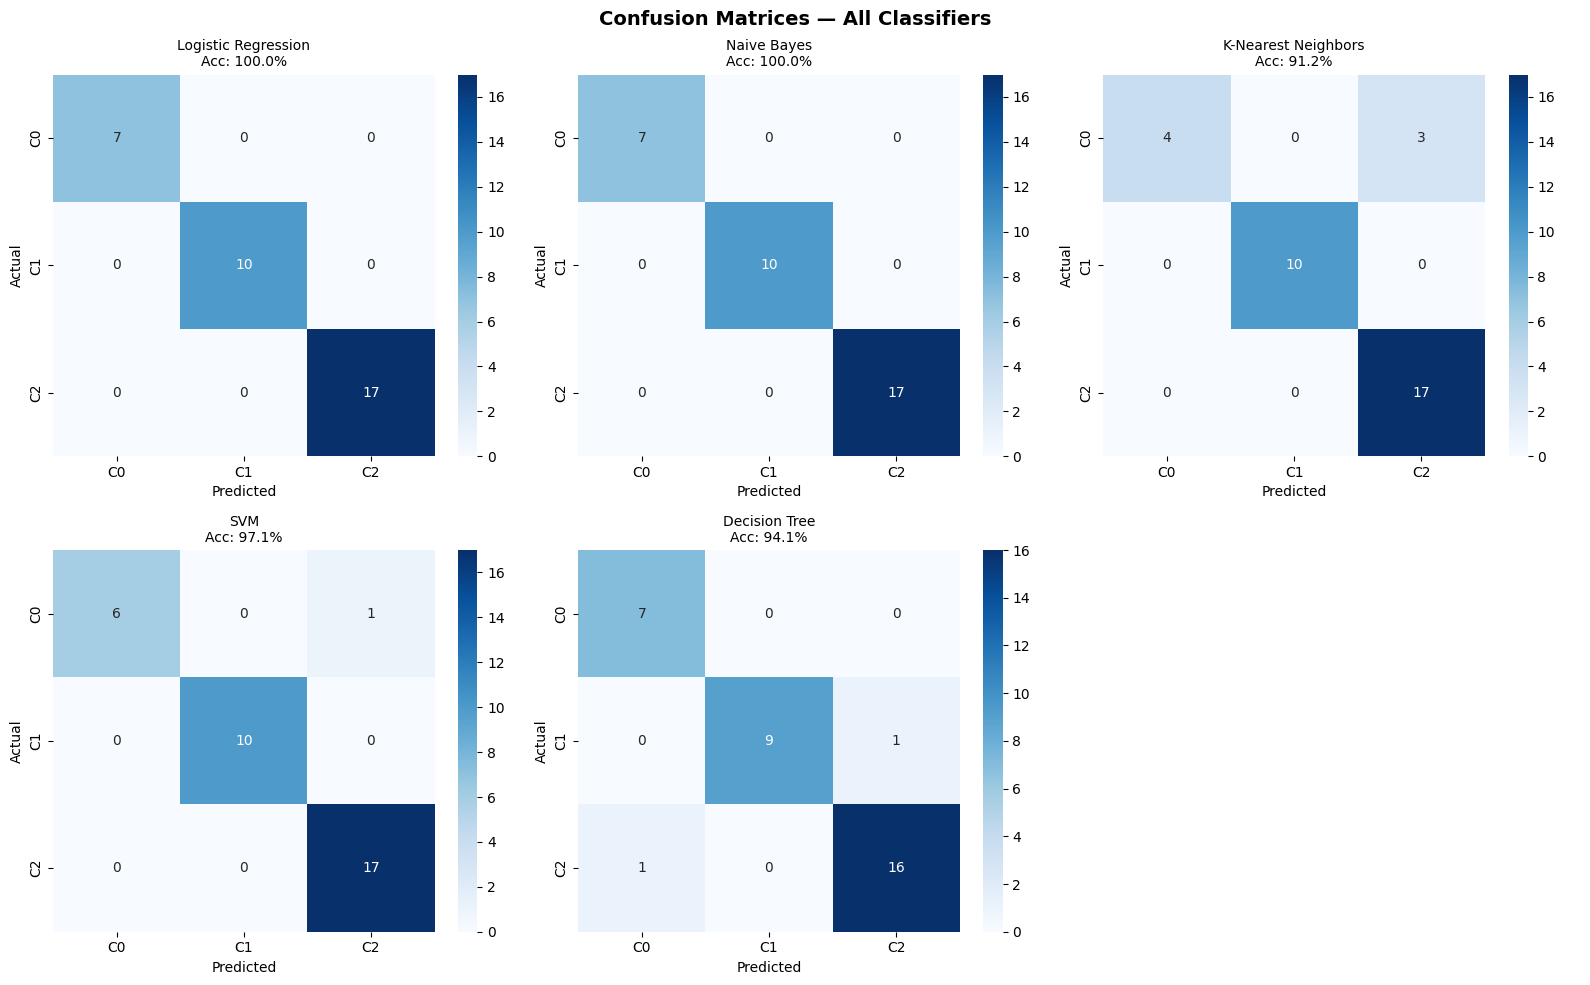


ROC-AUC Scores (One-vs-Rest):
-----------------------------------
  Logistic Regression       AUC = 1.0000
  Naive Bayes               AUC = 1.0000
  K-Nearest Neighbors       AUC = 1.0000
  SVM                       AUC = 1.0000
  Decision Tree             AUC = 0.9576


In [18]:
# ---- Confusion Matrix for each classifier ----
fig, axes=plt.subplots(2, 3, figsize=(16, 10))
# we create a grid of 6 subplots (2 rows x 3 columns)
axes=axes.flatten()  # flatten makes it easier to index as a 1D list

for i, (name, clf) in enumerate(classifiers.items()):
    y_pred=clf.predict(X_test)
    cm=confusion_matrix(y_test, y_pred)
    # confusion_matrix shows counts of correct and incorrect predictions per class
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[f'C{j}' for j in range(best_k)],
                yticklabels=[f'C{j}' for j in range(best_k)])
    axes[i].set_title(f'{name}\nAcc: {clf_results[name]*100:.1f}%', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].axis('off')  # hide the 6th empty subplot
plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plot_folder}/09_confusion_matrices.png')
plt.show()

# ---- ROC-AUC Scores ----
print("\nROC-AUC Scores (One-vs-Rest):")
print("-"*35)
for name, clf in classifiers.items():
    if hasattr(clf, 'predict_proba'):
        # predict_proba gives probability scores needed for ROC-AUC calculation
        y_prob=clf.predict_proba(X_test)
        auc=roc_auc_score(y_test, y_prob, multi_class='ovr')
        # multi_class='ovr' means One-vs-Rest — compares each class against all others
        print(f"  {name:<25} AUC = {auc:.4f}")
    else:
        print(f"  {name:<25} AUC = N/A (no probability output)")

## Step 15 — Ensemble Learning Models
We now train **6 ensemble models** — these combine multiple models for better accuracy:
- Random Forest (Bagging)
- AdaBoost (Boosting)
- Gradient Boosting (Boosting)
- XGBoost (Optimized Boosting)
- LightGBM (Fast Boosting)
- Stacking (Meta-Learning)

In [19]:
# ---- Define all ensemble models ----
ensembles={
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    # 100 decision trees vote together — majority class wins
    # Each tree is trained on a random sample of data and features

    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    # AdaBoost focuses more on samples that were wrongly classified before
    # Each new tree tries harder on the difficult examples

    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    # Trees are built one by one; each tree corrects the errors of the previous one
    # learning_rate controls how much each tree contributes

    'XGBoost': XGBClassifier(n_estimators=100, random_state=42,
                              use_label_encoder=False, eval_metric='mlogloss', verbosity=0),
    # XGBoost adds regularization (prevents overfitting) to standard gradient boosting
    # It is extremely fast and handles missing values natively

    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    # LightGBM grows trees leaf-wise instead of level-wise — faster on large datasets
    # verbose=-1 hides the training log messages

    'Stacking': StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000)),
            ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5))
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    )
    # Stacking trains multiple base models and then trains a meta-model
    # on their predictions — the meta-model learns when to trust which base model
    # cv=5 means 5-fold cross-validation is used when generating meta-features
}

ens_results={}  # stores accuracy of each ensemble model

for name, model in ensembles.items():
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    ens_results[name]=acc
    print(f"\n{'='*50}")
    print(f"Ensemble : {name}")
    print(f"Accuracy : {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Ensemble : Random Forest
Accuracy : 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Ensemble : AdaBoost
Accuracy : 97.06%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34


Ensemble : Gradient Boosting
Accuracy : 97.06%

Classification Report:
              precision    recall 

## Step 16 — Hyperparameter Tuning with GridSearchCV (Random Forest)
GridSearchCV tries all combinations of parameters and finds the best one using cross-validation.

In [20]:
param_grid={
    'n_estimators': [50, 100],  # test 50 and 100 trees
    'max_depth': [5, 10, None]  # test depths: 5, 10, or unlimited
}
# total combinations = 2 x 3 = 6

grid_search=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,           # 5-fold cross-validation for each combination
    scoring='accuracy',
    n_jobs=-1       # use all CPU cores to speed up the search
)
grid_search.fit(X_train, y_train)

best_params=grid_search.best_params_
best_rf=grid_search.best_estimator_
# best_estimator_ is the already-trained model with the best parameters

print(f"Best parameters found     : {best_params}")
print(f"Best CV accuracy          : {grid_search.best_score_*100:.2f}%")

y_pred_rf=best_rf.predict(X_test)
acc_rf=accuracy_score(y_test, y_pred_rf)
print(f"Tuned RF test accuracy    : {acc_rf*100:.2f}%")
ens_results['Random Forest (Tuned)']=acc_rf

Best parameters found     : {'max_depth': 5, 'n_estimators': 50}
Best CV accuracy          : 94.73%
Tuned RF test accuracy    : 100.00%


## Step 17 — Feature Importance (Random Forest)
Feature importance tells us which country indicators were most useful for predicting the cluster.

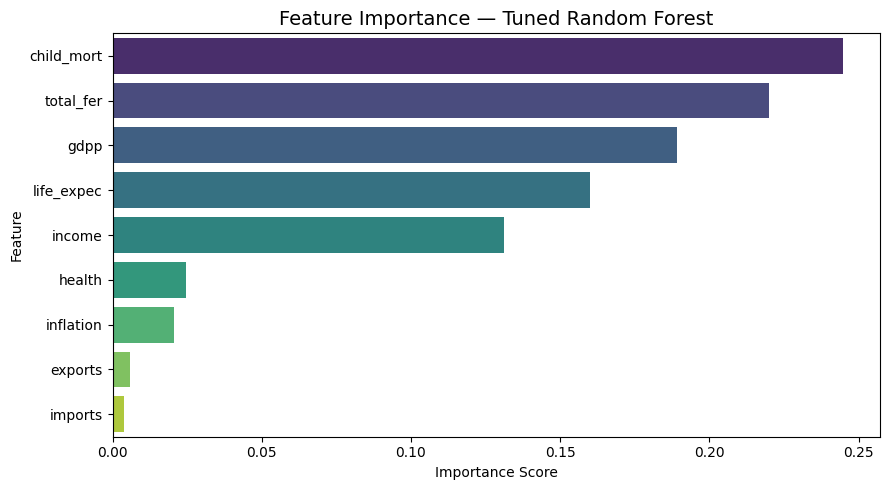


Feature importance ranking:
  child_mort       0.2450  ████████████████████████
  total_fer        0.2201  ██████████████████████
  gdpp             0.1890  ██████████████████
  life_expec       0.1600  ████████████████
  income           0.1312  █████████████
  health           0.0245  ██
  inflation        0.0206  ██
  exports          0.0059  
  imports          0.0037  


In [21]:
importances=best_rf.feature_importances_
# feature_importances_ gives a score for each feature showing how much it helped
feature_names=df_num.columns.tolist()

importance_df=pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df=importance_df.sort_values('Importance', ascending=False)
# sort from highest to lowest so we see the most important features first

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
# viridis palette gives a nice green-to-yellow gradient
plt.title('Feature Importance — Tuned Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{plot_folder}/10_feature_importance.png')
plt.show()

print("\nFeature importance ranking:")
for _, row in importance_df.iterrows():
    bar='█' * int(row['Importance']*100)
    # we draw a simple bar using block characters for visual effect
    print(f"  {row['Feature']:<15}  {row['Importance']:.4f}  {bar}")

## Step 18 — 5-Fold Cross-Validation
Cross-validation splits data into 5 parts and tests the model on each split.
This gives a much more reliable accuracy estimate than a single test set.

In [22]:
cv_scores=cross_val_score(best_rf, X_scaled, y, cv=5, scoring='accuracy')
# 5 iterations: train on 4 parts, test on 1 — rotates which part is the test set

print(f"Per-fold accuracies : {[round(s*100, 2) for s in cv_scores]}")
print(f"Mean CV Accuracy    : {cv_scores.mean()*100:.2f}%")
print(f"Std Dev of CV       : {cv_scores.std()*100:.2f}%")
# low std dev means the model performs consistently across different data splits

Per-fold accuracies : [np.float64(100.0), np.float64(100.0), np.float64(96.97), np.float64(87.88), np.float64(96.97)]
Mean CV Accuracy    : 96.36%
Std Dev of CV       : 4.45%


## Step 19 — Full Model Comparison
All classifiers and ensemble models compared side by side.


+------------------------------+----------+
| Model                        | Accuracy |
+------------------------------+----------+
| Logistic Regression          |  100.00% |
| Naive Bayes                  |  100.00% |
| Random Forest                |  100.00% |
| LightGBM                     |  100.00% |
| Stacking                     |  100.00% |
| Random Forest (Tuned)        |  100.00% |
| SVM                          |   97.06% |
| AdaBoost                     |   97.06% |
| Gradient Boosting            |   97.06% |
| Decision Tree                |   94.12% |
| XGBoost                      |   94.12% |
| K-Nearest Neighbors          |   91.18% |
+------------------------------+----------+


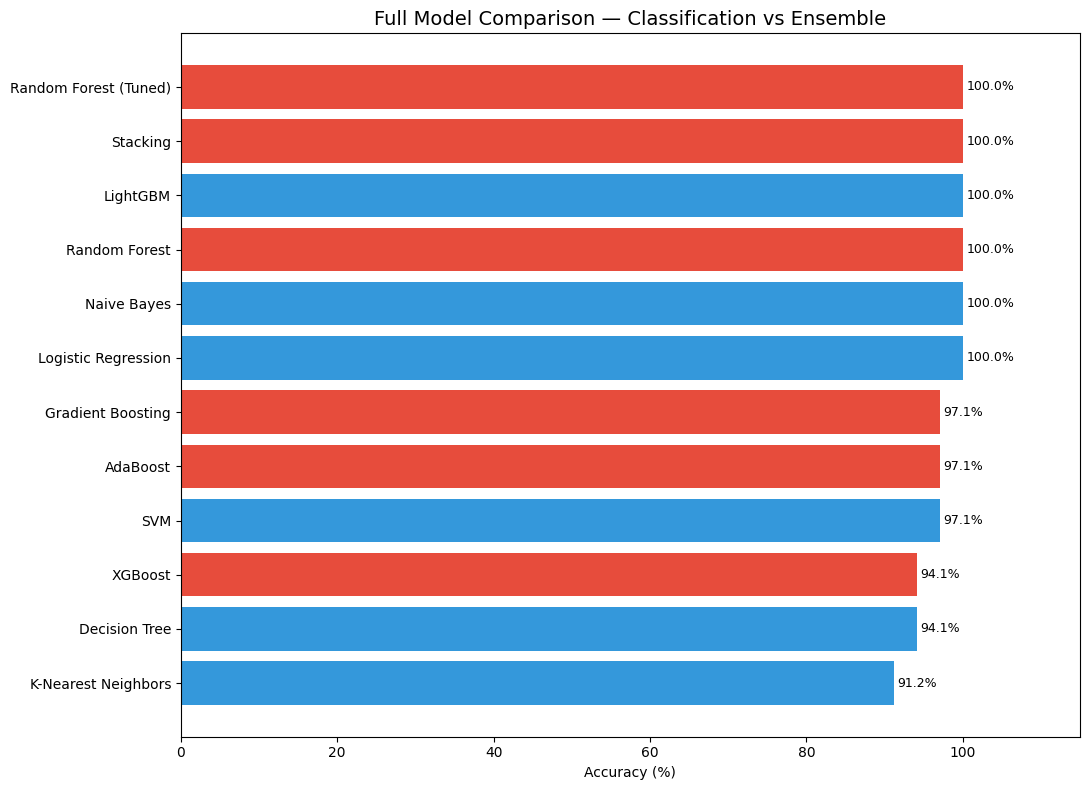

In [23]:
# Combine classification and ensemble results
all_results={**clf_results, **ens_results}
# ** unpacks both dictionaries and merges them into one

print("\n+------------------------------+----------+")
print("| Model                        | Accuracy |")
print("+------------------------------+----------+")
for name, acc in sorted(all_results.items(), key=lambda x: -x[1]):
    print(f"| {name:<28} | {acc*100:7.2f}% |")
print("+------------------------------+----------+")

# Plot all models as a horizontal bar chart
plt.figure(figsize=(11, 8))
sorted_all=dict(sorted(all_results.items(), key=lambda x: x[1]))
bar_colors=['#e74c3c' if 'Forest' in k or 'Boost' in k or 'Stack' in k
            else '#3498db' for k in sorted_all.keys()]
# red bars for ensemble models, blue for classifiers
plt.barh(list(sorted_all.keys()), [v*100 for v in sorted_all.values()],
         color=bar_colors)
plt.xlabel('Accuracy (%)')
plt.title('Full Model Comparison — Classification vs Ensemble', fontsize=14)
plt.xlim(0, 115)
for i, (name, acc) in enumerate(sorted_all.items()):
    plt.text(acc*100+0.5, i, f'{acc*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{plot_folder}/11_full_model_comparison.png')
plt.show()

## Step 20 — Cluster Profiling & Socio-Economic Observations (Section 14)
We compute the average of each feature per cluster to understand what each group represents.

In [24]:
df['country']=countries
profile=df.groupby('KMeans_Cluster')[list(df_num.columns)].mean().round(2)
# groupby groups rows by cluster; mean gives the average value of each feature per cluster
print("Average feature values per cluster:")
profile

Average feature values per cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [25]:
hm_cluster=profile['child_mort'].idxmax()   # cluster with highest child mortality
hi_gdp_cluster=profile['gdpp'].idxmax()     # cluster with highest GDP
lo_dev_cluster=profile['income'].idxmin()   # cluster with lowest income

print(f"""
OBSERVATIONS — Section 14
{'='*60}

Observation 1 — High-Mortality Cluster:
  Cluster {hm_cluster} has the highest average child mortality rate
  ({profile.loc[hm_cluster, 'child_mort']:.1f} per 1000 births) with the lowest income.
  These countries face serious healthcare access challenges and
  likely need international aid and infrastructure investment.

Observation 2 — Top-Tier Economic Zone:
  Cluster {hi_gdp_cluster} represents wealthy, developed nations with average
  GDP per capita of ${profile.loc[hi_gdp_cluster, 'gdpp']:,.0f} and life expectancy
  of {profile.loc[hi_gdp_cluster, 'life_expec']:.1f} years. These countries invest
  heavily in health ({profile.loc[hi_gdp_cluster, 'health']:.1f}% of GDP) and have
  very low child mortality rates.

Observation 3 — Low-Development Area:
  Cluster {lo_dev_cluster} has the lowest average income (${profile.loc[lo_dev_cluster, 'income']:,.0f})
  and high fertility rates ({profile.loc[lo_dev_cluster, 'total_fer']:.2f} births/woman),
  which is typical of countries with limited access to education
  and family planning resources.

Observation 4 — Clustering Algorithm Comparison:
  K-Means Silhouette Score       : {sil_score:.4f}
  All three methods (K-Means, DBSCAN, Hierarchical) were applied
  and compared visually using PCA 2D projections. K-Means gave
  the clearest separation for this dataset.

Observation 5 — DBSCAN Noise Points:
  DBSCAN identified {n_noise} outlier countries that don't fit into any
  dense cluster. These likely represent transition economies with
  unusual combinations of development indicators.
""")


OBSERVATIONS — Section 14

Observation 1 — High-Mortality Cluster:
  Cluster 1 has the highest average child mortality rate
  (93.0 per 1000 births) with the lowest income.
  These countries face serious healthcare access challenges and
  likely need international aid and infrastructure investment.

Observation 2 — Top-Tier Economic Zone:
  Cluster 0 represents wealthy, developed nations with average
  GDP per capita of $42,494 and life expectancy
  of 80.1 years. These countries invest
  heavily in health (8.8% of GDP) and have
  very low child mortality rates.

Observation 3 — Low-Development Area:
  Cluster 1 has the lowest average income ($3,942)
  and high fertility rates (5.01 births/woman),
  which is typical of countries with limited access to education
  and family planning resources.

Observation 4 — Clustering Algorithm Comparison:
  K-Means Silhouette Score       : 0.2833
  All three methods (K-Means, DBSCAN, Hierarchical) were applied
  and compared visually using PCA 2D 

## Step 21 — Save Final Results to CSV

In [26]:
output_cols=['country', 'child_mort', 'income', 'gdpp', 'life_expec',
             'KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']
# we include cluster labels from all 3 methods in the output

final_output=df[output_cols].copy()
final_output.to_csv('country_cluster_results.csv', index=False)
# index=False means we don't save row numbers — they add no value

print("✅ Results saved to: country_cluster_results.csv")
print("\nSample of final results:")
final_output.head(10)

✅ Results saved to: country_cluster_results.csv

Sample of final results:


,country,child_mort,income,gdpp,life_expec,KMeans_Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,Afghanistan,90.2,1610,553,56.2,1,0,2
1,Albania,16.6,9930,4090,76.3,2,0,1
2,Algeria,27.3,12900,4460,76.5,2,0,1
3,Angola,119.0,5900,3530,60.1,1,-1,1
4,Antigua and Barbuda,10.3,19100,12200,76.8,2,0,1
5,Argentina,14.5,18700,10300,75.8,2,0,1
6,Armenia,18.1,6700,3220,73.3,2,0,1
7,Australia,4.8,41400,51900,82.0,0,0,0
8,Austria,4.3,43200,46900,80.5,0,0,0
9,Azerbaijan,39.2,16000,5840,69.1,2,0,1


## Final Summary

In [27]:
print("="*62)
print("  CUSTOMER INTELLIGENCE SYSTEM — COMPLETE")
print("="*62)

best_overall=max(all_results, key=all_results.get)
best_acc=max(all_results.values())

lines=[
    f"  Dataset              : Country-data.csv (167 countries)",
    f"  Features Used        : {list(df_num.columns)}",
    "",
    "  CLUSTERING:",
    f"    K-Means   (k=3)    : Silhouette = {sil_score:.4f}",
    f"    DBSCAN             : {n_clusters_found} cluster(s), {n_noise} noise point(s)",
    f"    Hierarchical (k=3) : Applied with Ward linkage + Dendrogram",
    f"    K-Medoids  (k=3)   : Applied (if scikit-learn-extra available)",
    "",
    "  CLASSIFICATION (5 models):",
    f"    {', '.join(classifiers.keys())}",
    "",
    "  ENSEMBLE (6 models):",
    f"    {', '.join(ensembles.keys())}",
    "",
    f"  Best Overall Model   : {best_overall}",
    f"  Best Accuracy        : {best_acc*100:.2f}%",
    f"  RF Cross-Val Mean    : {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%",
    "",
    "  Output files         : plots/ folder + country_cluster_results.csv",
]

for line in lines:
    print(line)

print("="*62)
print("  All done! Notebook completed successfully.")
print("="*62)

  CUSTOMER INTELLIGENCE SYSTEM — COMPLETE
  Dataset              : Country-data.csv (167 countries)
  Features Used        : ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

  CLUSTERING:
    K-Means   (k=3)    : Silhouette = 0.2833
    DBSCAN             : 1 cluster(s), 30 noise point(s)
    Hierarchical (k=3) : Applied with Ward linkage + Dendrogram
    K-Medoids  (k=3)   : Applied (if scikit-learn-extra available)

  CLASSIFICATION (5 models):
    Logistic Regression, Naive Bayes, K-Nearest Neighbors, SVM, Decision Tree

  ENSEMBLE (6 models):
    Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM, Stacking

  Best Overall Model   : Logistic Regression
  Best Accuracy        : 100.00%
  RF Cross-Val Mean    : 96.36% +/- 4.45%

  Output files         : plots/ folder + country_cluster_results.csv
  All done! Notebook completed successfully.
